# Neural Network Implementation Comparison
Comparing custom neural network implementation with PyTorch and TensorFlow models for breast cancer classification.

## Overview
This notebook compares three implementations of the same neural network architecture:
1. Custom NumPy implementation (from previous notebook)
2. PyTorch implementation
3. TensorFlow/Keras implementation

In [2]:
# Common imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
import time
from joblib import load

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# TensorFlow imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
tf.random.set_seed(42)

## 1. Data Loading and Preprocessing
Loading the breast cancer dataset and preparing it for training

In [3]:
# Load the dataset
df = pd.read_csv('E:/Downloads/breast-cancer.csv')

# Preprocess the data
le = LabelEncoder()
for column in df.select_dtypes(include=['object']).columns:
    df[column] = le.fit_transform(df[column])

# Prepare features and target
X = df.drop(['diagnosis', 'id'], axis=1)
y = df['diagnosis']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors for PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.FloatTensor(y_train.values)
y_test_tensor = torch.FloatTensor(y_test.values)

# Convert to tensors for TensorFlow
X_train_tf = tf.convert_to_tensor(X_train_scaled, dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train.values, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test.values, dtype=tf.float32)

## 2. Load Custom Model Results
Loading the previously trained custom neural network model and its results

In [4]:
# Define the custom neural network class (needed for loading the model)
from sklearn.base import BaseEstimator, ClassifierMixin

class NeuralNetworkClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(16, 8), learning_rate=0.01, n_epochs=1000, threshold=0.3):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.threshold = threshold
        self.params = None
        
    def _initialize_parameters(self, n_features):
        np.random.seed(42)
        h1, h2 = self.hidden_layer_sizes
        return {
            "W1": np.random.randn(n_features, h1) * np.sqrt(2 / n_features),
            "b1": np.zeros((1, h1)),
            "W2": np.random.randn(h1, h2) * np.sqrt(2 / h1),
            "b2": np.zeros((1, h2)),
            "W3": np.random.randn(h2, 1) * np.sqrt(2 / h2),
            "b3": np.zeros((1, 1)),
        }
    
    def fit(self, X, y):
        self.params = self._initialize_parameters(X.shape[1])
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        return self
    
    def predict_proba(self, X):
        X = np.array(X)
        probas, _ = forward_propagation(X, self.params)
        return np.hstack([1 - probas, probas])
    
    def predict(self, X):
        probas = self.predict_proba(X)
        return (probas[:, 1] >= self.threshold).astype(int)

#Define the required helper functions
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward_propagation(X, params):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2)
    Z3 = A2 @ params["W3"] + params["b3"]
    A3 = sigmoid(Z3)
    return A3, {"A1": A1, "Z1": Z1, "A2": A2, "Z2": Z2, "Z3": Z3, "A3": A3}

In [5]:
# Load the saved custom model
custom_model = load('breast_cancer_neural_network.joblib')

# Get predictions and metrics for custom model
custom_predictions = custom_model.predict(X_test_scaled)
custom_metrics = {
    'accuracy': accuracy_score(y_test, custom_predictions),
    'precision': precision_score(y_test, custom_predictions),
    'recall': recall_score(y_test, custom_predictions),
    'f1': f1_score(y_test, custom_predictions)
}

print("Custom Model Performance:")
for metric, value in custom_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

Custom Model Performance:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9535
F1: 0.9762


## 3. PyTorch Implementation
Implementing the same neural network architecture using PyTorch

Epoch [100/1000]
Training Loss: 0.0592
Validation Loss: 0.0507

Early stopping at epoch 132


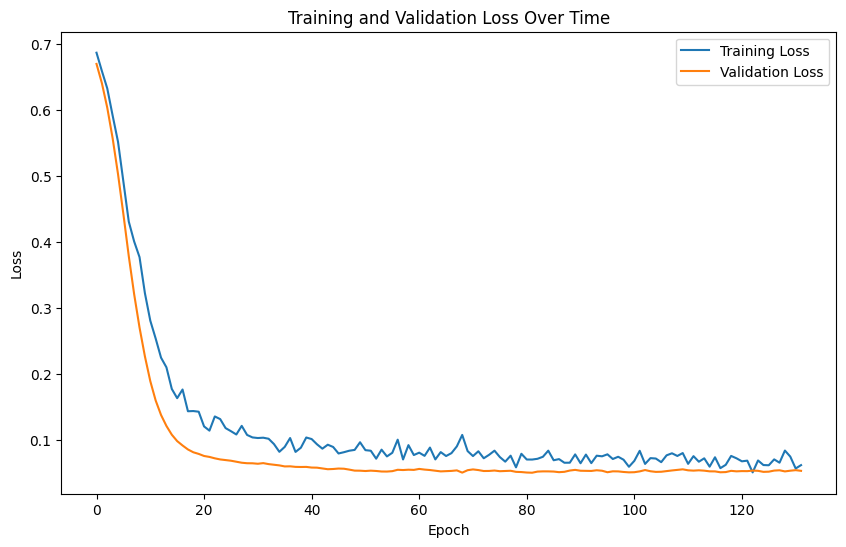


PyTorch Model Performance:
Accuracy: 0.9912
Precision: 1.0000
Recall: 0.9767
F1: 0.9882
Training_time: 2.0251


In [6]:
# PyTorch model definition
class BreastCancerNet(nn.Module):
    def __init__(self):
        super(BreastCancerNet, self).__init__()
        self.layer1 = nn.Linear(30, 16)
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.3)  # Add dropout with 0.3 probability
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)  # Apply dropout after first layer
        x = self.relu(self.layer2(x))
        x = self.dropout(x)  # Apply dropout after second layer
        x = self.sigmoid(self.layer3(x))
        return x

# Create the PyTorch model
pytorch_model = BreastCancerNet()
criterion = nn.BCELoss()
# Add weight decay (L2 regularization) and reduce learning rate
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.001, weight_decay=0.01)

# Training settings
n_epochs = 1000
batch_size = 32

# Create DataLoader for training and validation
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor.reshape(-1, 1))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor.reshape(-1, 1))
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Training loop
pytorch_start_time = time.time()
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 50  # Number of epochs to wait for improvement
counter = 0  # Counter for early stopping

for epoch in range(n_epochs):
    pytorch_model.train()
    epoch_losses = []
    
    # Training
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = pytorch_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    
    # Calculate average training loss for the epoch
    avg_train_loss = sum(epoch_losses) / len(epoch_losses)
    train_losses.append(avg_train_loss)
    
    # Validation
    pytorch_model.eval()
    val_epoch_losses = []
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            val_outputs = pytorch_model(batch_X)
            val_loss = criterion(val_outputs, batch_y)
            val_epoch_losses.append(val_loss.item())
    
    avg_val_loss = sum(val_epoch_losses) / len(val_epoch_losses)
    val_losses.append(avg_val_loss)
    
    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}]')
        print(f'Training Loss: {avg_train_loss:.4f}')
        print(f'Validation Loss: {avg_val_loss:.4f}\n')

pytorch_training_time = time.time() - pytorch_start_time

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluation
pytorch_model.eval()
with torch.no_grad():
    pytorch_predictions = (pytorch_model(X_test_tensor) >= 0.5).float().numpy()
    
pytorch_metrics = {
    'accuracy': accuracy_score(y_test, pytorch_predictions),
    'precision': precision_score(y_test, pytorch_predictions),
    'recall': recall_score(y_test, pytorch_predictions),
    'f1': f1_score(y_test, pytorch_predictions),
    'training_time': pytorch_training_time
}

print("\nPyTorch Model Performance:")
for metric, value in pytorch_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

## 4. TensorFlow/Keras Implementation
Implementing the same neural network architecture using TensorFlow/Keras

In [7]:
# Create the TensorFlow model
tf_model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(30,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
tf_model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Training
tf_start_time = time.time()
history = tf_model.fit(X_train_tf, y_train_tf,
                      epochs=1000,
                      batch_size=32,
                      verbose=0)
tf_training_time = time.time() - tf_start_time

# Evaluation
tf_predictions = (tf_model.predict(X_test_tf) >= 0.5).astype(int)
tf_metrics = {
    'accuracy': accuracy_score(y_test, tf_predictions),
    'precision': precision_score(y_test, tf_predictions),
    'recall': recall_score(y_test, tf_predictions),
    'f1': f1_score(y_test, tf_predictions),
    'training_time': tf_training_time
}

print("\nTensorFlow Model Performance:")
for metric, value in tf_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

e:\OneDrive\Documents\coding\Deep Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

TensorFlow Model Performance:
Accuracy: 0.9737
Precision: 0.9762
Recall: 0.9535
F1: 0.9647
Training_time: 71.2399


## 5. Performance Comparison
Comparing the performance metrics of all three implementations

<Figure size 1200x600 with 0 Axes>

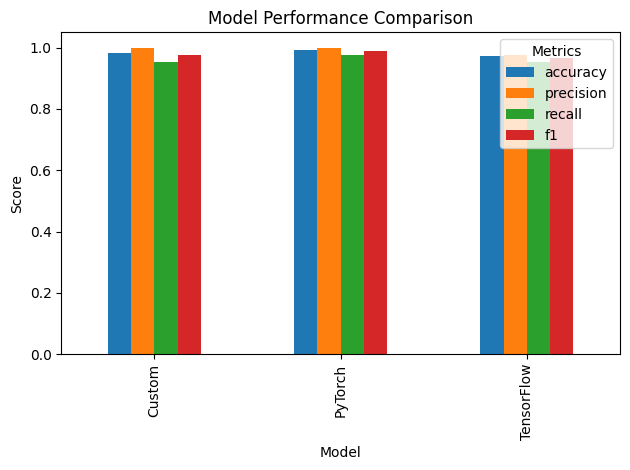

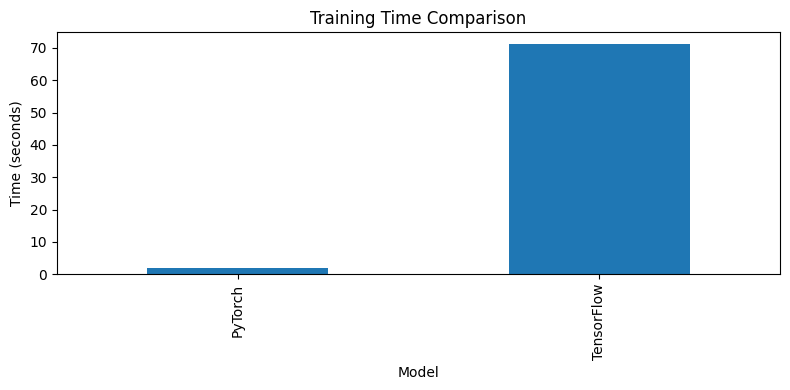


Detailed Performance Comparison:
            accuracy  precision  recall      f1  training_time
Custom        0.9825     1.0000  0.9535  0.9762            NaN
PyTorch       0.9912     1.0000  0.9767  0.9882         2.0251
TensorFlow    0.9737     0.9762  0.9535  0.9647        71.2399


In [8]:
# Combine all metrics
metrics_df = pd.DataFrame({
    'Custom': custom_metrics,
    'PyTorch': pytorch_metrics,
    'TensorFlow': tf_metrics
}).T

# Create bar plot for metrics comparison
plt.figure(figsize=(12, 6))
metrics_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

# Training time comparison (excluding custom model as it was pre-trained)
plt.figure(figsize=(8, 4))
training_times = pd.Series({
    'PyTorch': pytorch_metrics['training_time'],
    'TensorFlow': tf_metrics['training_time']
})
training_times.plot(kind='bar')
plt.title('Training Time Comparison')
plt.ylabel('Time (seconds)')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

# Print detailed comparison
print("\nDetailed Performance Comparison:")
print(metrics_df.round(4))

## 6. Model Architecture Visualization
Visualizing the architecture of all three models

In [16]:
# Simple model visualization using summary and print statements
print("\nTensorFlow Model Architecture:")
tf_model.summary()

print("\nPyTorch Model Architecture:")
print(pytorch_model)

print("\nCustom Model Architecture:")
print("Input Layer: 30 neurons")
print("Hidden Layer 1: 16 neurons (ReLU)")
print("Hidden Layer 2: 8 neurons (ReLU)")
print("Output Layer: 1 neuron (Sigmoid)")

# Print model summaries
print("PyTorch Model Architecture:")
print(pytorch_model)

print("\nTensorFlow Model Architecture:")
tf_model.summary()

print("\nCustom Model Architecture:")
print("Input Layer: 30 neurons")
print("Hidden Layer 1: 16 neurons (ReLU)")
print("Hidden Layer 2: 8 neurons (ReLU)")
print("Output Layer: 1 neuron (Sigmoid)")


TensorFlow Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,925 (7.52 KB)

 Trainable params: 641 (2.50 KB)

...

 Total params: 1,925 (7.52 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,284 (5.02 KB)


Custom Model Architecture:
Input Layer: 30 neurons
Hidden Layer 1: 16 neurons (ReLU)
Hidden Layer 2: 8 neurons (ReLU)
Output Layer: 1 neuron (Sigmoid)
